In [1]:
import os
os.getcwd()

'C:\\Users\\preya'

In [9]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\preya
['.anaconda', '.ansys', '.cfx', '.conda', '.condarc', '.continuum', '.cxlayout.ini', '.flrecent', '.fluentconf', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.matplotlib', '.vscode', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'cleanup-fluent-Radhe-19544.bat', 'cleanup-fluent-Radhe-5148.bat', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'Firstfile.ipynb', 'fluent-0-error.log', 'fourth.ipynb', 'LECTURE2.ipynb (list)', 'Links', 'list part (2) lect (14).ipynb', 'list part(1)', 'list part(1).ipynb', 'Local Settings', 'loops .ipynb', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{06f88032-dbbe-11f0-af50-c43a95f16a3a}.TxR.0.regtrans-ms', 'NTUSER.DAT{06f88032-dbbe-11f0-af50-c43a95f16a3a}.TxR.1.regtrans-ms', 'NTUSER.DAT{06f88032-dbbe-11f0-af50-c43a95f16a3a}.TxR.2.regtrans-ms', 'NTUSER.DAT{06f88032-dbbe-11f0-af50-c43a95f16a3a}.TxR.blf', 'NTUSER.DAT{06f88033-dbbe-11f0-

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# Define column names
index_names = ['UnitNumber', 'Cycle']
setting_names = ['OpSet1', 'OpSet2', 'OpSet3']
sensor_names = ['Sensor' + str(i) for i in range(1, 22)]

columns = index_names + setting_names + sensor_names

In [12]:
df = pd.read_csv('train_FD001.txt',
                 sep=r'\s+',
                 names=columns)

df.head()

,UnitNumber,Cycle,OpSet1,OpSet2,OpSet3,Sensor1,Sensor2,Sensor3,Sensor4,Sensor5,...,Sensor12,Sensor13,Sensor14,Sensor15,Sensor16,Sensor17,Sensor18,Sensor19,Sensor20,Sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [13]:
# Calculate max cycle for each engine
rul = df.groupby('UnitNumber')['Cycle'].max().reset_index()
rul.columns = ['UnitNumber', 'MaxCycle']

# Merge with original dataframe
df = df.merge(rul, on='UnitNumber')

# Calculate Remaining Useful Life
df['RUL'] = df['MaxCycle'] - df['Cycle']

# Drop helper column
df.drop('MaxCycle', axis=1, inplace=True)

df.head()

,UnitNumber,Cycle,OpSet1,OpSet2,OpSet3,Sensor1,Sensor2,Sensor3,Sensor4,Sensor5,...,Sensor13,Sensor14,Sensor15,Sensor16,Sensor17,Sensor18,Sensor19,Sensor20,Sensor21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [14]:
df.shape

(20631, 27)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   UnitNumber  20631 non-null  int64  
 1   Cycle       20631 non-null  int64  
 2   OpSet1      20631 non-null  float64
 3   OpSet2      20631 non-null  float64
 4   OpSet3      20631 non-null  float64
 5   Sensor1     20631 non-null  float64
 6   Sensor2     20631 non-null  float64
 7   Sensor3     20631 non-null  float64
 8   Sensor4     20631 non-null  float64
 9   Sensor5     20631 non-null  float64
 10  Sensor6     20631 non-null  float64
 11  Sensor7     20631 non-null  float64
 12  Sensor8     20631 non-null  float64
 13  Sensor9     20631 non-null  float64
 14  Sensor10    20631 non-null  float64
 15  Sensor11    20631 non-null  float64
 16  Sensor12    20631 non-null  float64
 17  Sensor13    20631 non-null  float64
 18  Sensor14    20631 non-null  float64
 19  Sensor15    20631 non-nul

In [16]:
df['RUL'].describe()

count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64

In [18]:
X = df.drop(['UnitNumber', 'Cycle', 'RUL'], axis=1)
y = df['RUL']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 41.5214287563132


In [26]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.6226512682402188


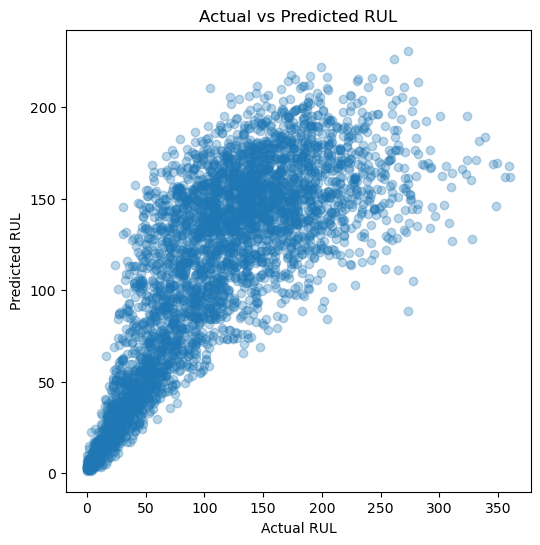

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")
plt.show()

In [35]:
df['RUL_clipped'] = df['RUL'].clip(upper=125)

In [36]:
X = df.drop(['UnitNumber', 'Cycle', 'RUL', 'RUL_clipped'], axis=1)
y = df['RUL_clipped']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("New RMSE:", rmse)

New RMSE: 18.76764868323054


In [37]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.7923860574722749


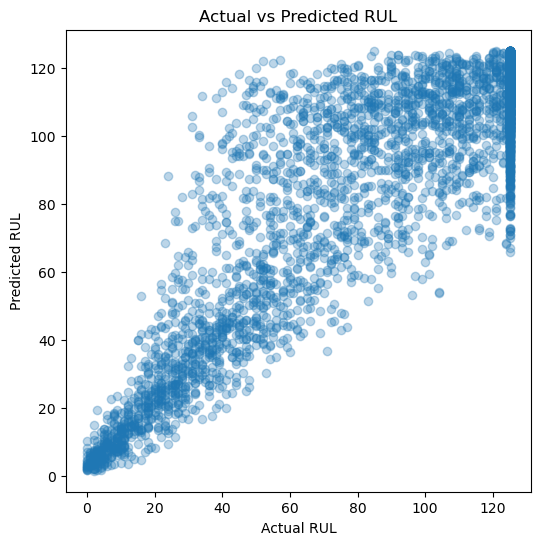

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")
plt.show()

In [39]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)

Sensor11    0.562374
Sensor9     0.131419
Sensor4     0.077251
Sensor12    0.047136
Sensor7     0.025112
Sensor14    0.022852
Sensor15    0.019775
Sensor21    0.017971
Sensor2     0.016151
Sensor3     0.014686
dtype: float64

In [41]:
top_features = feature_importance.head(10).index

X_top = df[top_features]
y_top = df['RUL_clipped']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y_top, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE with Top Features:", rmse)

RMSE with Top Features: 18.891977864882264


In [43]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.4/101.7 MB 28.6 MB/s eta 0:00:04
   ---- ----------------------------------- 11.0/101.7 MB 34.3 MB/s eta 0:00:03
   ------ --------------------------------- 15.5/101.7 MB 29.5 MB/s eta 0:00:03
   -------- ------------------------------- 21.2/101.7 MB 30.5 MB/s eta 0:00:03
   ----------- ---------------------------- 28.0/101.7 MB 29.6 MB/s eta 0:00:03
   ------------- -------------------------- 34.9/101.7 MB 29.9 MB/s eta 0:00:03
   --------------- ------------------------ 40.4/101.7 MB 29.5 MB/s eta 0:00:03
   ------------------ --------------------- 46.4/101.7 MB 29.2 MB/s eta 0:00:02
   -------------------- ------------------- 51.1/101.7 MB 28.5 MB/s eta 0:00:02
   ---------------------- ----------------- 56.6/101.7 MB 28.2 MB/s eta 0:00:02
   ------------------------- -------------- 64.2/101.7 MB 29.0 MB/s eta 0:00:02
   --------------------------- ------------ 69.5/1

In [44]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=200, learning_rate=0.05)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("XGBoost RMSE:", rmse)

XGBoost RMSE: 18.81029149824333


In [45]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("XGBoost R2:", r2)

XGBoost R2: 0.7914415597915649


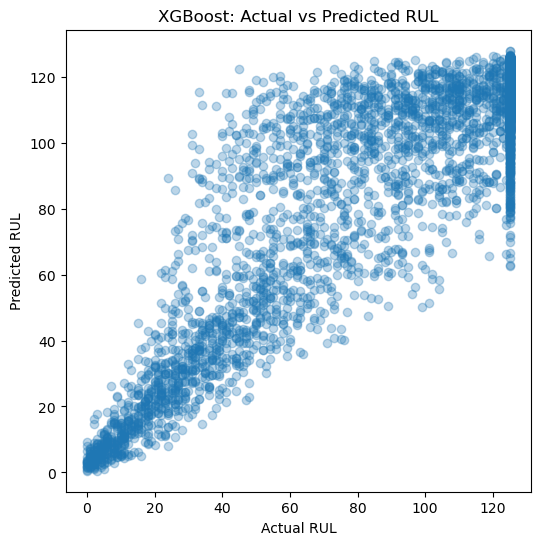

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost: Actual vs Predicted RUL")
plt.show()

In [48]:
print("Random Forest RMSE: 41.52")
print("XGBoost RMSE: 18.81")
print("Random Forest R2: 0.79")
print("XGBoost R2: 0.79")

Random Forest RMSE: 41.52
XGBoost RMSE: 18.81
Random Forest R2: 0.79
XGBoost R2: 0.79
